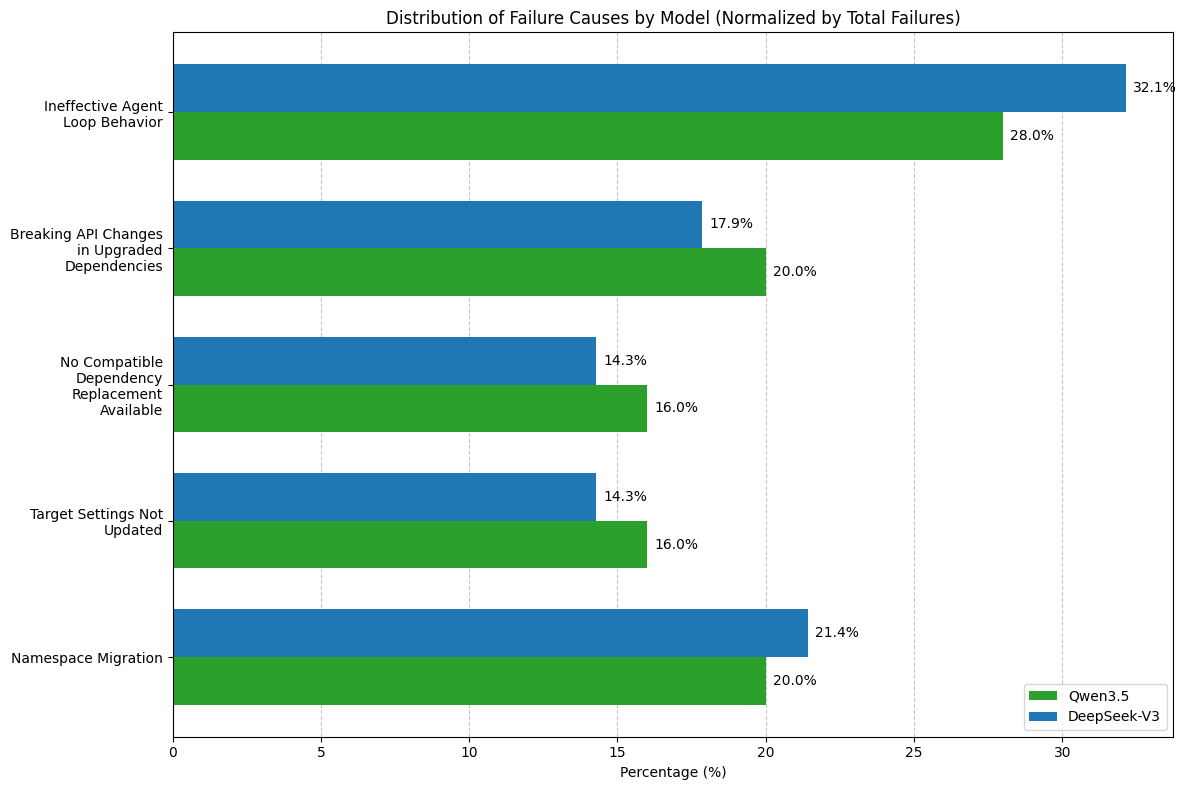

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

# 1. Input Data
data = {
    "Qwen3.5": {
        "Namespace Migration": 5,
        "Target Settings Not Updated": 4,
        "No Compatible Dependency Replacement Available": 4,
        "Breaking API Changes in Upgraded Dependencies": 5,
        "Ineffective Agent Loop Behavior": 7,
        "Total Failures": 25
    },
    "DeepSeek-V3": {
        "Namespace Migration": 6,
        "Target Settings Not Updated": 4,
        "No Compatible Dependency Replacement Available": 4,
        "Breaking API Changes in Upgraded Dependencies": 5,
        "Ineffective Agent Loop Behavior": 9,
        "Total Failures": 28
    }
}

# 2. Data Processing
categories = list(data["Qwen3.5"].keys())[:-1]

# Wrap long labels (limit to 20 characters per line)
wrapped_categories = [textwrap.fill(cat, width=20) for cat in categories]

# Calculate percentages based on Total Failures
qwen_pct = [
    (data["Qwen3.5"][cat] / data["Qwen3.5"]["Total Failures"]) * 100
    for cat in categories
]
deepseek_pct = [
    (data["DeepSeek-V3"][cat] / data["DeepSeek-V3"]["Total Failures"]) * 100
    for cat in categories
]

# 3. Chart Configuration
y = np.arange(len(categories))
height = 0.35

fig, ax = plt.subplots(figsize=(12, 8))

rects1 = ax.barh(y - height/2, qwen_pct, height, label='Qwen3.5', color='#2ca02c')
rects2 = ax.barh(y + height/2, deepseek_pct, height, label='DeepSeek-V3', color='#1f77b4')

# 4. Formatting and Display
ax.set_xlabel('Percentage (%)')
ax.set_title('Distribution of Failure Causes by Model (Normalized by Total Failures)')
ax.set_yticks(y)
ax.set_yticklabels(wrapped_categories)
ax.legend()

# --- Thêm đường dóng (Grid lines) ---
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
# ------------------------------------

# Add exact % labels to the end of each bar
ax.bar_label(rects1, fmt='%.1f%%', padding=5)
ax.bar_label(rects2, fmt='%.1f%%', padding=5)

plt.tight_layout()
plt.show()

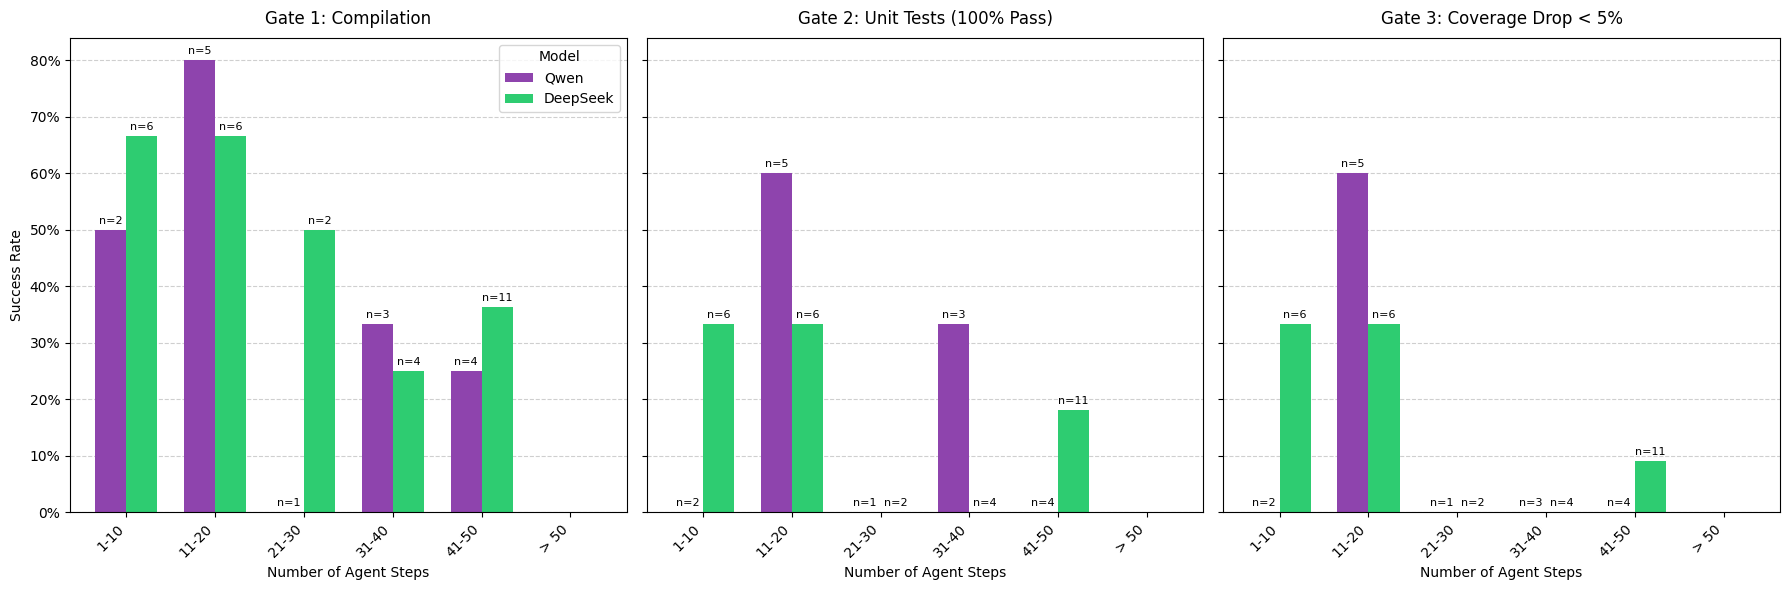

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

def get_gates_data_by_bin(filepath):
    bins = {
        '1-10': {'total': 0, 'g1_success': 0, 'g2_success': 0, 'g3_success': 0},
        '11-20': {'total': 0, 'g1_success': 0, 'g2_success': 0, 'g3_success': 0},
        '21-30': {'total': 0, 'g1_success': 0, 'g2_success': 0, 'g3_success': 0},
        '31-40': {'total': 0, 'g1_success': 0, 'g2_success': 0, 'g3_success': 0},
        '41-50': {'total': 0, 'g1_success': 0, 'g2_success': 0, 'g3_success': 0},
        '> 50': {'total': 0, 'g1_success': 0, 'g2_success': 0, 'g3_success': 0}
    }

    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)

    for project, metrics in data.items():
        steps = metrics.get('step_count', 0)

        # Lấy các chỉ số
        compilation_success = metrics.get('compilation_success', False)
        passed_tests = metrics.get('passed_tests', 0)
        total_tests = metrics.get('total_tests', -1)
        baseline_coverage = metrics.get('baseline_coverage', 0.0)
        line_coverage = metrics.get('line_coverage', 0.0)

        # Đánh giá theo 3 Gate tuần tự
        gate1_ok = (compilation_success is True)
        gate2_ok = gate1_ok and (passed_tests == total_tests)
        gate3_ok = gate2_ok and ((baseline_coverage - line_coverage) < 5.0)

        # Phân loại nhóm bước
        if 1 <= steps <= 10: bin_key = '1-10'
        elif 11 <= steps <= 20: bin_key = '11-20'
        elif 21 <= steps <= 30: bin_key = '21-30'
        elif 31 <= steps <= 40: bin_key = '31-40'
        elif 41 <= steps <= 50: bin_key = '41-50'
        elif steps > 50: bin_key = '> 50'
        else: continue

        bins[bin_key]['total'] += 1
        if gate1_ok: bins[bin_key]['g1_success'] += 1
        if gate2_ok: bins[bin_key]['g2_success'] += 1
        if gate3_ok: bins[bin_key]['g3_success'] += 1

    # Tính toán tỷ lệ cho 3 gates
    rates_g1, rates_g2, rates_g3, totals = [], [], [], []
    for key in bins:
        total = bins[key]['total']
        totals.append(total)
        if total > 0:
            rates_g1.append((bins[key]['g1_success'] / total) * 100)
            rates_g2.append((bins[key]['g2_success'] / total) * 100)
            rates_g3.append((bins[key]['g3_success'] / total) * 100)
        else:
            rates_g1.append(0.0)
            rates_g2.append(0.0)
            rates_g3.append(0.0)

    return rates_g1, rates_g2, rates_g3, totals, list(bins.keys())

# 1. Đường dẫn file
file_qwen = r"D:\capstone_project\MYGRATE---Capstone-Project\test\artifacts\eval-qwen.json"
file_deepseek = r"D:\capstone_project\MYGRATE---Capstone-Project\test\artifacts\eval-deepseek.json"

# 2. Xử lý dữ liệu
q_g1, q_g2, q_g3, q_totals, labels = get_gates_data_by_bin(file_qwen)
d_g1, d_g2, d_g3, d_totals, _ = get_gates_data_by_bin(file_deepseek)

# 3. Cấu hình biểu đồ (3 subplots ngang nhau)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

x = np.arange(len(labels))
width = 0.35

gate_data = [
    (q_g1, d_g1, 'Gate 1: Compilation'),
    (q_g2, d_g2, 'Gate 2: Unit Tests (100% Pass)'),
    (q_g3, d_g3, 'Gate 3: Coverage Drop < 5%')
]

# Hàm hiển thị nhãn n=?
def add_labels(ax, rects, totals):
    for rect, total in zip(rects, totals):
        height = rect.get_height()
        if total > 0:
            ax.annotate(f'n={total}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

# 4. Vẽ từng subplot
for i, ax in enumerate(axes):
    q_rates, d_rates, title = gate_data[i]

    rects1 = ax.bar(x - width/2, q_rates, width, label='Qwen', color='#8E44AD')
    rects2 = ax.bar(x + width/2, d_rates, width, label='DeepSeek', color='#2ECC71')

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('Number of Agent Steps')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # Chỉ định dạng trục Y cho subplot đầu tiên
    if i == 0:
        ax.set_ylabel('Success Rate')
        ax.yaxis.set_major_formatter(PercentFormatter(100))
        ax.legend(title='Model')

    # Thêm nhãn n=?
    add_labels(ax, rects1, q_totals)
    add_labels(ax, rects2, d_totals)

plt.tight_layout()
plt.show()

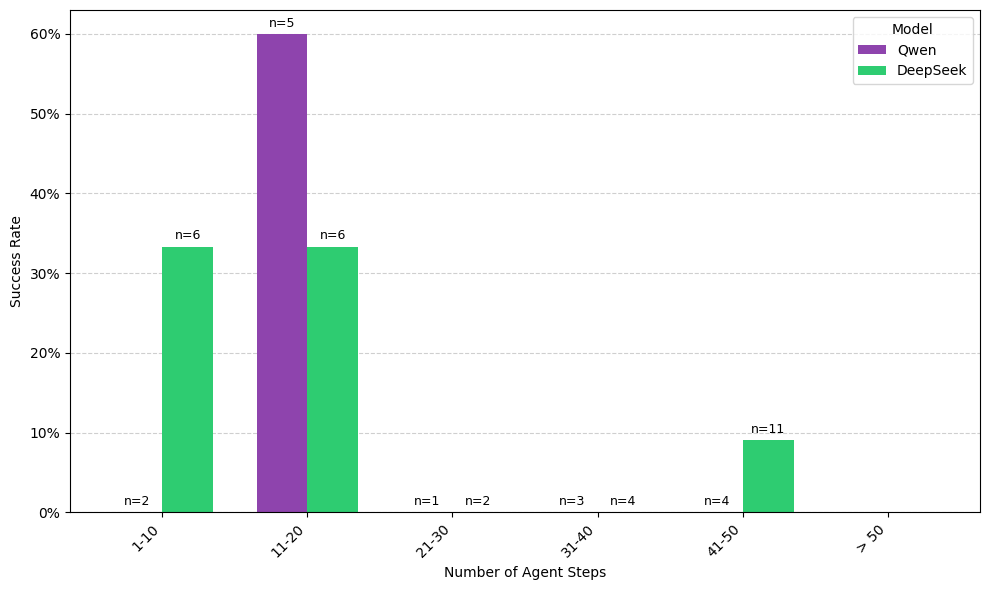

In [9]:
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

def get_success_data_by_bin(filepath):
    # Khởi tạo các bin mới theo nhịp 10
    bins = {
        '1-10': {'success': 0, 'total': 0},
        '11-20': {'success': 0, 'total': 0},
        '21-30': {'success': 0, 'total': 0},
        '31-40': {'success': 0, 'total': 0},
        '41-50': {'success': 0, 'total': 0},
        '> 50': {'success': 0, 'total': 0}
    }

    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)

    for project, metrics in data.items():
        steps = metrics.get('step_count', 0)

        # Logic tính success
        compilation_success = metrics.get('compilation_success', False)
        baseline_coverage = metrics.get('baseline_coverage', 0.0)
        line_coverage = metrics.get('line_coverage', 0.0)
        passed_tests = metrics.get('passed_tests', 0)
        total_tests = metrics.get('total_tests', -1)

        success = (
            (compilation_success is True) and
            ((baseline_coverage - line_coverage) < 5.0) and
            (passed_tests == total_tests)
        )

        # Phân loại vào bin mới
        if 1 <= steps <= 10:
            bin_key = '1-10'
        elif 11 <= steps <= 20:
            bin_key = '11-20'
        elif 21 <= steps <= 30:
            bin_key = '21-30'
        elif 31 <= steps <= 40:
            bin_key = '31-40'
        elif 41 <= steps <= 50:
            bin_key = '41-50'
        elif steps > 50:
            bin_key = '> 50'
        else:
            continue # Bỏ qua nếu step <= 0

        bins[bin_key]['total'] += 1
        if success:
            bins[bin_key]['success'] += 1

    rates = []
    totals = []
    # Chỉ giữ lại các nhãn có logic để vẽ đồ thị
    for key in bins:
        total = bins[key]['total']
        if total > 0:
            rate = (bins[key]['success'] / total) * 100
        else:
            rate = 0.0
        rates.append(rate)
        totals.append(total)

    return rates, totals, list(bins.keys())

# 1. Đường dẫn file
file_qwen = r"D:\capstone_project\MYGRATE---Capstone-Project\test\artifacts\eval-qwen.json"
file_deepseek = r"D:\capstone_project\MYGRATE---Capstone-Project\test\artifacts\eval-deepseek.json"

# 2. Xử lý dữ liệu
qwen_rates, qwen_totals, labels = get_success_data_by_bin(file_qwen)
deepseek_rates, deepseek_totals, _ = get_success_data_by_bin(file_deepseek)

# 3. Cấu hình biểu đồ
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, qwen_rates, width, label='Qwen', color='#8E44AD')
rects2 = ax.bar(x + width/2, deepseek_rates, width, label='DeepSeek', color='#2ECC71')

# 4. Định dạng hiển thị
ax.set_ylabel('Success Rate')
ax.set_xlabel('Number of Agent Steps')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.legend(title='Model')

# Hiển thị nhãn n=? lên đầu cột
def add_labels(rects, totals):
    for rect, total in zip(rects, totals):
        height = rect.get_height()
        if total > 0:
            ax.annotate(f'n={total}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

add_labels(rects1, qwen_totals)
add_labels(rects2, deepseek_totals)

plt.tight_layout()
plt.show()

In [10]:
import json

# Đường dẫn đến file eval-qwen
filepath = r"D:\capstone_project\MYGRATE---Capstone-Project\test\artifacts\eval-qwen.json"

def calculate_avg_llm_calls(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)

    total_calls = 0
    project_count = len(data)

    if project_count == 0:
        print("Tệp JSON rỗng.")
        return

    for project, metrics in data.items():
        # Ưu tiên lấy 'llm_calls', nếu không có thì lấy 'step_count'
        calls = metrics.get('llm_calls', metrics.get('step_count', 0))
        total_calls += calls

    avg_calls = total_calls / project_count

    print(f"Tổng số dự án: {project_count}")
    print(f"Tổng số LLM calls (hoặc Agent Steps): {total_calls}")
    print(f"Trung bình (Average): {avg_calls:.2f} calls/dự án")

# Thực thi
calculate_avg_llm_calls(filepath)

Tổng số dự án: 15
Tổng số LLM calls (hoặc Agent Steps): 404
Trung bình (Average): 26.93 calls/dự án
